---
## This plot will create  "Figure 1" for the paper draft of Feb. '26
##### Noel Siegert, 2/24/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'Fig1_submissionFeb26.ipynb'

In [5]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [6]:
# open geophysical data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW.data.astype(bool)

# station var's
tx_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.detrend_anom.roll11.nc').Tx # note new filename 11/21
td_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.detrend_anom.roll11.nc').Td # note new filename 11/21

# tmean (raw)
tx_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.nc').Tx
tn_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tn.nc').Tn
tmean_da = (tx_raw_da + tn_raw_da) / 2

# raw dewpoint
td_raw_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.nc').Td

# SST 
sst_da = xr.open_dataset('/dx02/data/nsiegert/oisst_station_cirleavg/ALLSTATIONS.1.5deg.daily.sst.1.9.2025.nc').sst.sel(time=slice('1990-01-01', '2023-12-31'))
sst_det_da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.sst.detrend_anom.roll11.nc').sst.sel(time=slice('1990-01-01', '2023-12-31')) # note new filename 11/21

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

# Analysis

In [7]:
## average Tx and td anom's during coastal MHW days 


# create MHW composites of important var's and add to gdf so we can plot

# station-mean (detrended anom) Tmax for MHW days and all days, for all szn, cold szn, and warm szn
gdf['Tx_det_mean'] = tx_det_da.mean(dim='time')
gdf['Tx_det_mean_w'] = tx_det_da.where(warmszn_mask).mean(dim='time')
gdf['Tx_det_mean_c'] = tx_det_da.where(coldszn_mask).mean(dim='time')
gdf['Tx_det_mhw_mean'] = tx_det_da.where(mhw_mask).mean(dim='time')
gdf['Tx_det_mhw_mean_w'] = tx_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['Tx_det_mhw_mean_c'] = tx_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

# station-mean (detrended anom) Dewpoint for MHW days and all days, for all szn, cold szn, and warm szn
gdf['Td_det_mean'] = td_det_da.mean(dim='time')
gdf['Td_det_mean_w'] = td_det_da.where(warmszn_mask).mean(dim='time')
gdf['Td_det_mean_c'] = td_det_da.where(coldszn_mask).mean(dim='time')
gdf['Td_det_mhw_mean'] = td_det_da.where(mhw_mask).mean(dim='time')
gdf['Td_det_mhw_mean_w'] = td_det_da.where(mhw_mask*warmszn_mask).mean(dim='time')
gdf['Td_det_mhw_mean_c'] = td_det_da.where(mhw_mask*coldszn_mask).mean(dim='time')

In [8]:
# binned lat profiles of tx and td and tn
tx_det_mhw_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tx_det_mhw_mean'].to_numpy())
tx_det_mhw_binned_w, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tx_det_mhw_mean_w'].to_numpy())
tx_det_mhw_binned_c, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Tx_det_mhw_mean_c'].to_numpy())

td_det_mhw_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Td_det_mhw_mean'].to_numpy())
td_det_mhw_binned_w, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Td_det_mhw_mean_w'].to_numpy())
td_det_mhw_binned_c, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=np.arange(-60, 71, 3), lats=gdf['LAT'].to_numpy(), dat=gdf['Td_det_mhw_mean_c'].to_numpy())

/home/nsiegert/projects/coastal_sst/code/analysis/coastal_analysis_fns.py:52: RuntimeWarning: Mean of empty slice
  binned_means.append(np.nanmean(dat[binmask*no_inf_mask]))


## For every coastal SST decile (bin), what is the frequency of being in < Var > threshold?

In [9]:
# generate mask for terrestrial tx, td, and HI < 10th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.1)
tx10_mask = tx_raw_da.groupby("time.dayofyear") <= hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.1)
td10_mask = td_raw_da.groupby("time.dayofyear") <= hk

# generate mask for terrestrial tx, td > 90th percentile
hh = tx_raw_da.groupby("time.dayofyear").quantile(0.9)
tx90_mask = tx_raw_da.groupby("time.dayofyear") > hh

hk = td_raw_da.groupby("time.dayofyear").quantile(0.9)
td90_mask = td_raw_da.groupby("time.dayofyear") > hk

In [10]:
%%time

## embarrassingly parallelizeable code... (takes ~1 min)

print('starting')
sstbins = np.arange(0, 1.1, 0.1)

# arrays to hold output
sstbinned_tx90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_tx90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_tx10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_tx10_c = np.zeros(shape=(10, len(gdf)))

sstbinned_td90_all = np.zeros(shape=(10, len(gdf))) # row = sst bin, col = each unique station
sstbinned_td90_w = np.zeros(shape=(10, len(gdf))) 
sstbinned_td90_c = np.zeros(shape=(10, len(gdf))) 
sstbinned_td10_all = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_w = np.zeros(shape=(10, len(gdf)))
sstbinned_td10_c = np.zeros(shape=(10, len(gdf)))

# for each bin
for i in range(10):
    
    # quantiles for bin edges
    lo = sstbins[i]
    hi = sstbins[i+1]
    print(i, sstbins[i], sstbins[i+1])
    
    # generate mask for SST falling within that quantile range
    loqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i])
    hiqtiles = sst_da.groupby("time.dayofyear").quantile(sstbins[i+1])
    sst_bin_mask = (sst_da.groupby("time.dayofyear") >= loqtiles) * (sst_da.groupby("time.dayofyear") < hiqtiles)
    
    # WITHIN THAT SST BIN: compute frequequency of exceeding Tx 90th %ile or being lower than Tx 10th %ile (also for warm and cold seasons)
    sstbinned_tx90_all[i,:] = tx90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx90_w[i,:] = tx90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx90_c[i,:] = tx90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

    sstbinned_tx10_all[i,:] = tx10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_tx10_w[i,:] = tx10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_tx10_c[i,:] = tx10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    # ALSO WITHIN THAT SST BIN: compute frequequency of exceeding Td 90th %ile or being lower than Td 10th %ile (also for warm and cold seasons)
    sstbinned_td90_all[i,:] = td90_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td90_w[i,:] = td90_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td90_c[i,:] = td90_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data
    
    sstbinned_td10_all[i,:] = td10_mask.where(sst_bin_mask).mean(dim='time').data
    sstbinned_td10_w[i,:] = td10_mask.where(sst_bin_mask*warmszn_mask).mean(dim='time').data
    sstbinned_td10_c[i,:] = td10_mask.where(sst_bin_mask*coldszn_mask).mean(dim='time').data

print('done')

starting
0 0.0 0.1
1 0.1 0.2
2 0.2 0.30000000000000004
3 0.30000000000000004 0.4
4 0.4 0.5
5 0.5 0.6000000000000001
6 0.6000000000000001 0.7000000000000001
7 0.7000000000000001 0.8
8 0.8 0.9
9 0.9 1.0
done
CPU times: user 7min 11s, sys: 44.5 s, total: 7min 56s
Wall time: 1min 19s


# plot

### Tx and Td Anomalies during coastal MHW conditions

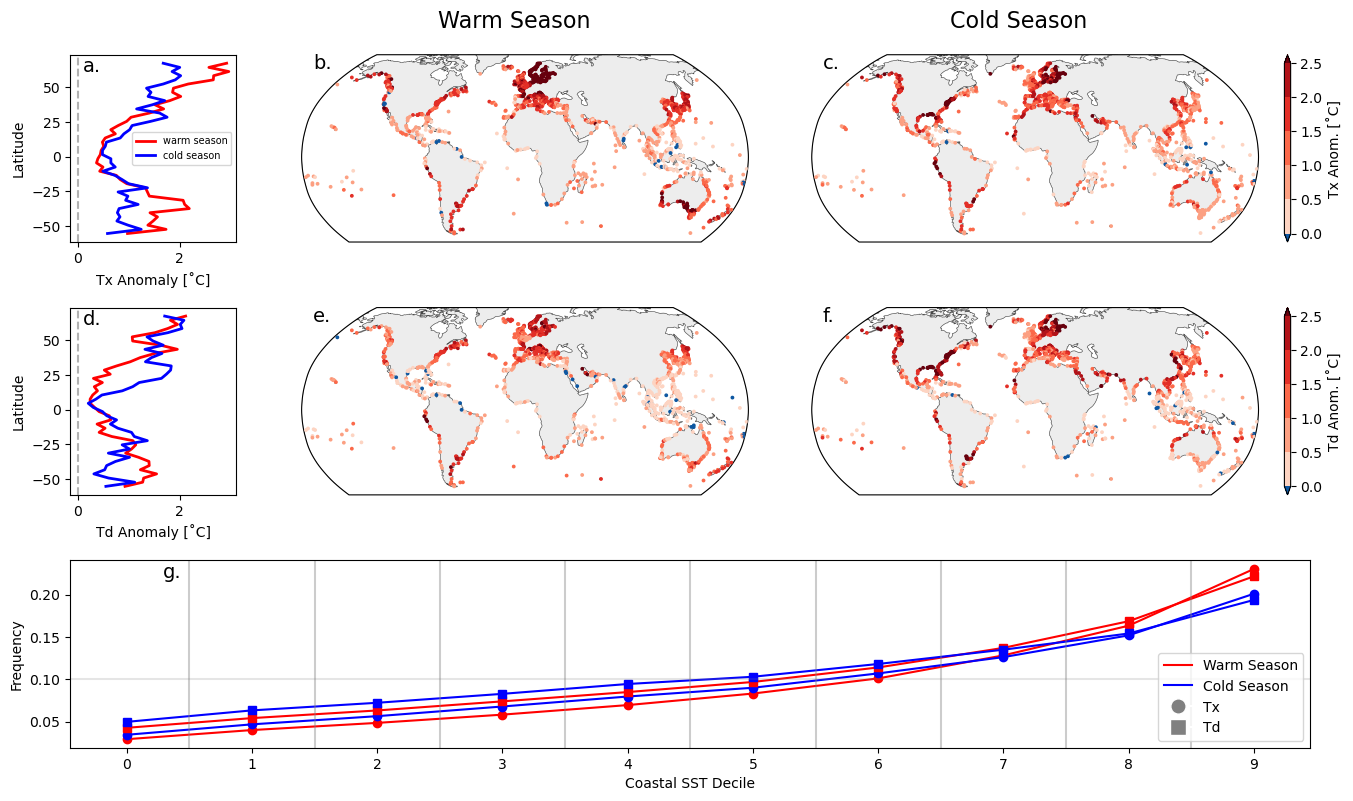

In [11]:
# make the plot

# set cmap
vmin = 0
vmax = 2.5
ncol_i = 6
bounds_i = np.linspace(vmin, vmax, ncol_i)
bluecolors = plt.get_cmap('Blues')(np.linspace(0,1,21))
cols = plt.get_cmap('Reds')(np.linspace(0,1,len(bounds_i)+1))
cmap_i = colors.ListedColormap(cols[1:-1])
cmap_i.set_over(cols[-1])
cmap_i.set_under(bluecolors[-4])
norm_i = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


# setup axes
nrows = 3
ncols = 3
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1, 3, 3]) 
gs.update(wspace=0.1, hspace=0.35)


ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
ax3 = fig.add_subplot(gs[1,0], sharex=ax0)
ax4 = fig.add_subplot(gs[1,1], projection=ccrs.Robinson())
ax5 = fig.add_subplot(gs[1,2], projection=ccrs.Robinson())
ax6 = fig.add_subplot(gs[2,:])

## ROW 0
# ax0: lat profiles for Tx
ax0.plot(tx_det_mhw_binned_w, bin_midpoints, color='r', lw=2, label='warm season')
ax0.plot(tx_det_mhw_binned_c, bin_midpoints, color='b', lw=2, label='cold season')

ax0.set(ylabel='Latitude', xlabel='Tx Anomaly [˚C]')
ax0.axvline(color='grey', ls='--', alpha=0.6)
ax0.legend(fontsize=7)

# ax1: Tx_mhw during warm season
gdf.plot(column='Tx_det_mhw_mean_w', ax=ax1, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax2: Tx_mhw during cold season
gdf.plot(column='Tx_det_mhw_mean_c', ax=ax2, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)
    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax1, ax2],
                    orientation="vertical",
                    extend='both',
                    label="Tx Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


## ROW 1
# ax3: lat profiles for Td
ax3.plot(td_det_mhw_binned_w, bin_midpoints, color='r', lw=2, label='warm season')
ax3.plot(td_det_mhw_binned_c, bin_midpoints, color='b', lw=2, label='cold season')

ax3.set(ylabel='Latitude', xlabel='Td Anomaly [˚C]')
ax3.axvline(color='grey', ls='--', alpha=0.6)

# ax4: Td_mhw during warm season
gdf.plot(column='Td_det_mhw_mean_w', ax=ax4, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

# ax5: Td_mhw during cold season
gdf.plot(column='Td_det_mhw_mean_c', ax=ax5, cmap=cmap_i, norm=norm_i, transform=ccrs.PlateCarree(), markersize=3, zorder=10)

    
# cbar
sm = plt.cm.ScalarMappable(norm=norm_i, cmap=cmap_i)
sm.set_array([])

cbar = fig.colorbar(sm,  
                    ax=[ax4, ax5],
                    orientation="vertical",
                    extend='both',
                    label="Td Anom. [˚C]",
                    pad=0.025,
                    use_gridspec=True,
                    fraction=0.025, 
                    ticks=bounds_i,
                    aspect=30)


# Map Cosmetics
for ax in [ax1, ax2, ax4, ax5]:
    ax.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
    ax.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0) 



# ax6: <var> extreme vs. SST Decile
tx90curve_w = []
tx90curve_c = []
td90curve_w = []
td90curve_c = []
xs = np.array(range(10))

for i in range(10):

    # grab the means
    tx90curve_w.append(np.nanmean(sstbinned_tx90_w[i,:]))
    tx90curve_c.append(np.nanmean(sstbinned_tx90_c[i,:]))
    td90curve_w.append(np.nanmean(sstbinned_td90_w[i,:]))
    td90curve_c.append(np.nanmean(sstbinned_td90_c[i,:]))
    
#     ax3.scatter(i, np.nanmean(sstbinned_tx90_w[i,:]), color='r', marker='+')
#     ax3.scatter(i, np.nanmean(sstbinned_tx90_c[i,:]), color='b', marker='+')

#     ax3.scatter(i, np.nanmean(sstbinned_td90_w[i,:]), color='r', marker='x')
#     ax3.scatter(i, np.nanmean(sstbinned_td90_c[i,:]), color='b', marker='x')
    
ax6.plot(xs, tx90curve_w, color='r', marker='o')
ax6.plot(xs, tx90curve_c, color='b', marker='o')
ax6.plot(xs, td90curve_w, color='r', marker='s')
ax6.plot(xs, td90curve_c, color='b', marker='s')
    
ax6.set_xticks(np.arange(0, 10, 1))
ax6.set(title='', xlabel='Coastal SST Decile', ylabel='Frequency')

# vertical line
for l in np.arange(0.5, 8.6, 1):
    ax6.axvline(l, color='gray', alpha=0.4)

ax6.axhline(0.1, color='grey', alpha=0.2)
    
# legend
legend_elements = [Line2D([0], [0], color='r', label='Warm Season'),
                   Line2D([0], [0], color='b', label='Cold Season'),
                   Line2D([0], [0], marker='o', color='w', label='Tx',
                          markerfacecolor='grey', markersize=11),
                   Line2D([0], [0], marker='s', color='w', label='Td',
                          markerfacecolor='grey', markersize=11)]

ax6.legend(handles=legend_elements, loc='lower right')


## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

i = 0
for ax in [ax0, ax1, ax2, ax3, ax4, ax5, ax6]:
    if i==0 or i==3 or i==6:
        ax.text(s='{}.'.format(letters[i]), x=0.075, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)
    else:
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
    i += 1

fig.text(x=0.355, y=0.91, s='Warm Season', fontsize=16)
fig.text(x=0.675, y=0.91, s='Cold Season', fontsize=16)

# now = datetime.now() # get datetime
# fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

# SAVE FIGURE
# plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/Fig1_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()